# Data Aggregation & Statistical Visualization Pipeline

This notebook handles the post-inference data processing, statistical analysis, and visual generation for the MLLM abstract visual reasoning benchmark. It transitions the raw JSON predictions into the structured metrics and publication-ready figures presented in the final manuscript.

### 🎯 Core Objectives
- **Data Standardization & Parsing:** Merges raw inference JSON files from multiple models and uses Regex to extract binary accuracy arrays (e.g., `[0, 1, 0, 1]`) from raw text outputs.
- **LLM-as-a-Judge Evaluation:** Utilizes models like DeepSeek-Chat to automatically evaluate and score other MLLMs' predictions against ground-truth labels containing multiple acceptable answers.
- **Granular Capability Profiling:** Calculates success ratios and performance percentages categorized by specific **Knowledge Domains** (e.g., *Public Figures, Popular Media*) and **Visual Styles** (e.g., *Caricature, Minimalism, Visual Pun*).
- **Publication-Ready Data Visualization:** Generates the high-fidelity Matplotlib figures used in the paper, including:
  - A dumbbell plot comparing Full Corpus Accuracy ($ACC$) vs. Recognized Subset Accuracy ($ACC^*$), separating models into *Leading*, *Middle*, and *Trailing* tiers.
  - A domain profile line chart highlighting specific model anomalies (e.g., Gemini's massive lead in *Public Figures*, GPT's inversion in *Linguistic Expressions*).
  - A dense, color-mapped style heatmap visualizing model weaknesses across distinct artistic renderings.
- **Dataset Management:** Includes utilities to automatically extract specific image ID subsets from the main corpus for manual review.

### 📊 Evaluated Model Tiers
The analysis processes and visualizes data for 8 distinct foundation models:
* **Leading Tier:** Gemini, GPT
* **Middle Tier:** Grok, Claude, GLM, Llama
* **Trailing Tier:** Qwen, Phi

### 📁 Input / Output
* **Inputs:** Raw model prediction files (e.g., `GPT-4o.json`, `claude-3-sonnet.json`, `3 grok_result.json`), ground-truth labels (`labels.json`), and the raw image corpus.
* **Outputs:** Cleaned evaluation data (`merged_results.json`, `processed_data.json`), isolated image sub-folders (`extracted_images/`), and finalized manuscript figures (`overall_acc.pdf`, `domain_profile.png`, `style_heatmap_compact.png`).

In [302]:
import os
import shutil

def extract_images(source_folder, destination_folder, image_list):
    # Create destination folder if it doesn't exist
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
        print(f"Created destination folder: {destination_folder}")
    
    # List to track successful and failed extractions
    extracted = []
    not_found = []
    
    # Process each image in the list
    for image_name in image_list:
        # Add .jpg extension
        image_filename = f"{image_name}.jpg"
        source_path = os.path.join(source_folder, image_filename)
        destination_path = os.path.join(destination_folder, image_filename)
        
        # Check if source file exists
        if os.path.isfile(source_path):
            # Copy the file
            shutil.copy2(source_path, destination_path)
            extracted.append(image_filename)
        else:
            not_found.append(image_filename)
    
    # Print summary
    print(f"\nExtraction complete!")
    print(f"Successfully extracted {len(extracted)} images")
    
    if extracted:
        print("Extracted images:")
        for img in extracted:
            print(f"  - {img}")
    
    if not_found:
        print("\nImages not found:")
        for img in not_found:
            print(f"  - {img}")

# Define folders and image list
source_folder = "img"
destination_folder = "extracted_images"
# image_list = ['0020', '0022', '0023', '0024', '0026', '0028', '0029', '0073', '0075']

# Run the extraction
extract_images(source_folder, destination_folder, result)

Created destination folder: extracted_images

Extraction complete!
Successfully extracted 766 images
Extracted images:
  - 0020.jpg
  - 0022.jpg
  - 0023.jpg
  - 0024.jpg
  - 0026.jpg
  - 0028.jpg
  - 0029.jpg
  - 0073.jpg
  - 0075.jpg
  - 0083.jpg
  - 0087.jpg
  - 0096.jpg
  - 0106.jpg
  - 0117.jpg
  - 0123.jpg
  - 0140.jpg
  - 0154.jpg
  - 0180.jpg
  - 0183.jpg
  - 0189.jpg
  - 0190.jpg
  - 0194.jpg
  - 0196.jpg
  - 0201.jpg
  - 0204.jpg
  - 0209.jpg
  - 0222.jpg
  - 0224.jpg
  - 0229.jpg
  - 0237.jpg
  - 0238.jpg
  - 0241.jpg
  - 0244.jpg
  - 0246.jpg
  - 0247.jpg
  - 0250.jpg
  - 0251.jpg
  - 0253.jpg
  - 0254.jpg
  - 0255.jpg
  - 0256.jpg
  - 0257.jpg
  - 0258.jpg
  - 0259.jpg
  - 0260.jpg
  - 0261.jpg
  - 0280.jpg
  - 0281.jpg
  - 0283.jpg
  - 0298.jpg
  - 0312.jpg
  - 0313.jpg
  - 0361.jpg
  - 0421.jpg
  - 0422.jpg
  - 0443.jpg
  - 0444.jpg
  - 0445.jpg
  - 0448.jpg
  - 0449.jpg
  - 0457.jpg
  - 0491.jpg
  - 0494.jpg
  - 0495.jpg
  - 0499.jpg
  - 0505.jpg
  - 0523.jpg
  - 0534.j

In [64]:
def calculate_percentages(category_totals, category_lists):
    result = {}
    
    for category, total in category_totals.items():
        if category in category_lists:
            # Calculate percentages by dividing each value by the category total
            percentages = [round((value / total) * 100, 2) for value in category_lists[category]]
            result[category] = percentages
    
    return result

# Given totals for each category
category_totals = {
    "Public Figures": 1024,
    "Popular Media": 668,
    "Linguistic Representations": 954,
    "Literary Works": 883
}

# Given lists for each category
category_lists = {
    "Public Figures": [442, 417, 905, 571, 576, 554, 335, 83],
    "Popular Media": [542, 454, 551, 391, 364, 409, 205, 59],
    "Linguistic Representations": [691, 400, 583, 404, 303, 272, 160, 79],
    "Literary Works": [743, 658, 710, 604, 564, 542, 366, 99]
}

# Calculate percentages
percentages = calculate_percentages(category_totals, category_lists)

# Display the results
for category, percent_list in percentages.items():
    print(f"{category}: {percent_list}")

Public Figures: [43.16, 40.72, 88.38, 55.76, 56.25, 54.1, 32.71, 8.11]
Popular Media: [81.14, 67.96, 82.49, 58.53, 54.49, 61.23, 30.69, 8.83]
Linguistic Representations: [72.43, 41.93, 61.11, 42.35, 31.76, 28.51, 16.77, 8.28]
Literary Works: [84.14, 74.52, 80.41, 68.4, 63.87, 61.38, 41.45, 11.21]


In [ ]:
import os
import base64
import json
from openai import OpenAI
import requests
import httpx
def process_images(folder_path):
    client = OpenAI(
    base_url="https://api.xty.app/v1", 
    api_key="xxxx",
    http_client=httpx.Client(
        base_url="https://api.xty.app/v1",
        follow_redirects=True,
    ),
    )
    output_file = os.path.join(folder_path, 'grok_infer.json')

    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            results = json.load(f)
    else:
        results = {}
    
    valid_extensions = ('.jpg', '.jpeg', '.png')
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    
    for img_file in image_files:
        key = os.path.splitext(img_file)[0]
        
        # Skip if already processed
        if key in results:
            print(f"Skipping {img_file} - already processed")
            continue
            
        img_path = os.path.join(folder_path, img_file)
        
        try:
            # Read and encode image with proper data URI format
            with open(img_path, 'rb') as f:
                img_base = base64.b64encode(f.read()).decode('utf-8')
                # Add the appropriate data URI prefix based on file extension
                if img_file.lower().endswith(('.jpg', '.jpeg')):
                    img_base = f"data:image/jpeg;base64,{img_base}"
                elif img_file.lower().endswith('.png'):
                    img_base = f"data:image/png;base64,{img_base}"
                    

            completion = client.chat.completions.create(
              model="grok-3",
              messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content":[{"type": "image_url", "image_url": {"url": img_base}},
                                            {"type": "text", "text": "Concisely answer the question on the image!"}]}
              ]
            )
            value = completion.choices[0].message.content
            results[key] = value
            print(key,'|',value)

            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            
        except Exception as e:
            print(f"Error processing {img_file}: {str(e)}")
            results[key] = "Error: " + str(e)
            # Save results even if there's an error
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
    
    return output_file

# Usage
folder_path = "img"
output_file = process_images(folder_path)
print(f"Results saved to: {output_file}")

In [8]:
import json
import re
import os

def extract_binary_list(text):
    """Extract binary list from text using regex."""
    # Look for patterns like [0], [1], [0, 1], etc.
    match = re.search(r'\[(\d+(?:,\s*\d+)*)\]', text)
    if match:
        # Convert the matched string to a list of integers
        binary_string = match.group(1)
        binary_list = [int(digit.strip()) for digit in binary_string.split(',')]
        return binary_list
    else:
        return "none"

def process_dictionary(input_file, output_file):
    # Create output directory if it doesn't exist
    output_dir = os.path.dirname(output_file)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Read the input JSON file
    try:
        with open(input_file, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"Error: {input_file} is not a valid JSON file.")
        return
    except FileNotFoundError:
        print(f"Error: {input_file} not found.")
        return
    
    # Process each key-value pair
    result = {}
    for key, value in data.items():
        binary_list = extract_binary_list(value)
        result[key] = binary_list
    
    # Write the results to the output JSON file
    try:
        with open(output_file, 'w') as f:
            json.dump(result, f)
        print(f"Successfully processed the dictionary and saved to {output_file}")
    except Exception as e:
        print(f"Error saving to {output_file}: {e}")

input_file = "LLMs/3 grok_result.json"  # Change this to your input file path
output_file = "LLMs/processed_data.json"  # Change this to your desired output file path
process_dictionary(input_file, output_file)

Successfully processed the dictionary and saved to LLMs/processed_data.json


In [6]:
import json
import os

# Set the path to the LLMs folder
folder_path = "LLMs"

# Read each JSON file into its corresponding dictionary
labelD = json.load(open(os.path.join(folder_path, 'labels.json'), encoding='utf-8'))

gptD = json.load(open(os.path.join(folder_path, 'GPT-4o.json'), encoding='utf-8'))
cldD = json.load(open(os.path.join(folder_path, 'claude-3-sonnet.json'), encoding='utf-8'))
gemD = json.load(open(os.path.join(folder_path, 'gemini-2.0-flash-exp.json'), encoding='utf-8'))
glmD = json.load(open(os.path.join(folder_path, 'GLM-4V-Plus.json'), encoding='utf-8'))
lamD = json.load(open(os.path.join(folder_path, 'Llama-3.2-90B.json'), encoding='utf-8'))
qwnD = json.load(open(os.path.join(folder_path, 'Qwen-QVQ-72B-Preview.json'), encoding='utf-8'))

In [14]:
import json
import os
from collections import OrderedDict

def merge_dicts_to_lists(dicts_list):
    # Create an OrderedDict to maintain key order
    merged = OrderedDict()
    
    # Generate keys in order from "0001" to "3529"
    ordered_keys = [f"{i:04d}" for i in range(1, 3530)]
    
    # For each key in order, create a list of values from each dictionary
    for key in ordered_keys:
        merged[key] = [d[key] for d in dicts_list]
    
    return merged

# Create list of dictionaries in the desired order
dicts_list = [labelD, gptD, cldD, gemD, glmD, lamD, qwnD]

# Merge dictionaries
merged_dict = merge_dicts_to_lists(dicts_list)

# Save to JSON file
output_path = os.path.join(folder_path, 'merged_results.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(merged_dict, f, ensure_ascii=False, indent=2)

In [22]:
prompt= """
Task: Evaluate image recognition results from 6 different LLMs against a standard label.

Input Format:
- A list of 7 strings
- Index 0: Standard label (may contain multiple acceptable answers separated by semicolons)
- Indices 1-6: Recognition results from 6 different LLMs

Evaluation Rules:
1. Compare each LLM's response to the standard label
2. For multiple predictions from an LLM:
   - Use the most confident prediction if confidence levels are indicated
   - Use the first prediction if multiple equal predictions are given
3. For labels with multiple acceptable answers (separated by semicolons), matching any one answer is considered correct

Output Format:
- A list of 6 binary values (1 for correct, 0 for incorrect)

Example:
Input: ["Amy Winehouse", "Amy Winehouse", "The image appears to be a cartoonish depiction resembling Amy Winehouse...", "Jennifer Aniston", "The image is a depiction of Amy Winehouse.", "The image appears to be a cartoon representation of Amy Winehouse...", "Dark hair... (followed by multiple suggestions including Selena Gomez, Rihanna...)"]
Output: [1,1,0,1,1,0]

INPUT:

"""

In [16]:
key = "xxxx"

In [25]:
# Please install OpenAI SDK first: `pip3 install openai`

from openai import OpenAI
result={}
client = OpenAI(api_key=key, base_url="https://api.deepseek.com")

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=[
        {"role": "system", "content": "You are a helpful assistant"},
        {"role": "user", "content": prompt+ str(merged_dict["0001"])},
    ],
    stream=False
)
result["0001"] = response.choices[0].message.content
print(response.choices[0].message.content)

Output: [0, 0, 0, 0, 1, 0]

Explanation:
- **LLM 1**: "Dolly Parton" does not match the standard label "Adele". (0)
- **LLM 2**: The response does not identify any specific individual, so it does not match "Adele". (0)
- **LLM 3**: "Taylor Swift" does not match the standard label "Adele". (0)
- **LLM 4**: The response states it cannot identify the celebrity, so it does not match "Adele". (0)
- **LLM 5**: The response suggests "Adele" as a possible match, which is correct. (1)
- **LLM 6**: The response does not clearly identify "Adele" and instead speculates without a definitive answer, so it does not match. (0)


In [35]:
import requests


url = "https://api.ainewserver.com/v1/chat/completions"

headers = {
    "Authorization": "xxx",
    "content-type": "application/json"
}
data = {
    "messages": [
        {
            "role": "user",
            "content": "hello,can you process long text,answer concisely",
        }
    ],
    "model": "gemini-2.0-flash-exp"
}

response = requests.post(url, headers=headers, json=data)
data = json.loads(response.text)
value = data['choices'][0]['message']['content']   
print(value)

Yes, I can process long text and answer concisely.



In [54]:
# read merged_results
import json

with open('LLMs/merged_results.json', 'r', encoding='utf-8') as file:
    merged_dict = json.load(file)

print(len(merged_dict))


3529


In [64]:
import json

# Read the first JSON file
with open('json/labels.json', 'r') as file1:
    dic1 = json.load(file1)

# Read the second JSON file
with open('json/result_3.json', 'r') as file2:
    dic2 = json.load(file2)

# Create a new dictionary to store merged results
merged_dict = {}

# Merge the dictionaries
for key in dic1.keys():
    merged_dict[key] = [dic1[key], dic2[key]]

# Save the merged dictionary to a new JSON file
with open('result_4.json', 'w', encoding='utf-8') as outfile:
    json.dump(merged_dict, outfile, indent=4)

In [94]:
import json

# Read the original JSON file
with open('json/result_3.json', 'r') as file:
    data = json.load(file)


with open('output.json', 'w') as file:
    json.dump(data, file, separators=(',', ':'))

In [99]:
import json

# Read the original JSON file
# Read the original JSON file
with open('output.json', 'r') as file:
    data = json.load(file)

# Save to a new JSON file with custom formatting
with open('output2.json', 'w') as file:
    # Opening brace
    file.write('{\n')
    
    # Get all keys
    keys = list(data.keys())
    
    # Iterate through items
    for i, key in enumerate(keys):
        # Format each value compactly
        compact_value = json.dumps(data[key], separators=(',', ':'))
        
        # Write key-value pair
        if i < len(keys) - 1:
            file.write(f'    "{key}": {compact_value},\n')
        else:
            file.write(f'    "{key}": {compact_value}\n')
    
    # Closing brace
    file.write('}')

In [98]:
import json

def count_image_types(json_file):
    # Read the JSON file
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Count image types
    counts = {}
    for item in data.values():
        image_type = item[-1]  # Get the last element of the list
        counts[image_type] = counts.get(image_type, 0) + 1
    
    return counts

# Example usage:
result = count_image_types('json/label.json')
print(result)

{'Memoji': 88, 'Caricature': 959, 'Cartoon': 46, 'Minimalism': 149, 'Iconography': 1, 'Emoji Combination': 649, 'Symbolism': 128, 'Visual Pun': 692, 'Illustration': 813, 'Surrealism': 4}


In [98]:
import json

def sum_binary_lists(json_file, category):
    # Read data from JSON file
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Initialize list to store sums for each position 
    sums = [0] * 8
    
    # Iterate through each item in the data
    for key, value in data.items():
        # Check if item matches the requested category
        if value[3] == category:
            # Add up binary values at each position
            binary_list = value[4]
            for i in range(8):
                sums[i] += binary_list[i]
                
    return sums

# Example usage:
json_file = "Labels/labels.json"  # Replace with your JSON file path
print("Memoji:", sum_binary_lists(json_file, "Memoji"))
print("Caricature:", sum_binary_lists(json_file, "Caricature"))
print("Cartoon:", sum_binary_lists(json_file, "Cartoon"))
print("Minimalism:", sum_binary_lists(json_file, "Minimalism"))
print("Symbolism:", sum_binary_lists(json_file, "Symbolism"))
print("Illustration:", sum_binary_lists(json_file, "Illustration"))
print("Visual Pun:", sum_binary_lists(json_file, "Visual Pun"))
print("Emoji Combination:", sum_binary_lists(json_file, "Emoji Combination"))

# la = [1024,668,954,883]
total=[88,959,46,149,128,813,692,649]

Memoji: [44, 59, 81, 69, 38, 64, 39, 9]
Caricature: [426, 422, 869, 532, 576, 543, 308, 83]
Cartoon: [37, 30, 41, 28, 32, 30, 21, 6]
Minimalism: [108, 76, 113, 91, 84, 83, 48, 8]
Symbolism: [101, 66, 104, 70, 58, 79, 37, 1]
Illustration: [688, 611, 667, 563, 536, 515, 341, 93]
Visual Pun: [475, 294, 405, 299, 250, 216, 132, 58]
Emoji Combination: [536, 370, 465, 316, 233, 247, 139, 61]


In [100]:
categories = [
    ("Memoji", [44, 59, 81, 69, 38, 64, 39, 9]),
    ("Caricature", [426, 422, 869, 532, 576, 543, 308, 83]),
    ("Cartoon", [37, 30, 41, 28, 32, 30, 21, 6]),
    ("Minimalism", [108, 76, 113, 91, 84, 83, 48, 8]),
    ("Symbolism", [101, 66, 104, 70, 58, 79, 37, 1]),
    ("Illustration", [688, 611, 667, 563, 536, 515, 341, 93]),
    ("Visual Pun", [475, 294, 405, 299, 250, 216, 132, 58]),
    ("Emoji Combination", [536, 370, 465, 316, 233, 247, 139, 61])
]

# The corresponding total values for each category
totals = [88, 959, 46, 149, 128, 813, 692, 649]

# Dictionary to store results
results = {}

# Iterate over the categories and corresponding total values
for index, (name, numbers) in enumerate(categories):
    total_value = totals[index]
    # Perform the division for each element in the current category list
    ratios = [round(num / total_value, 4) for num in numbers]
    results[name] = ratios

# Print out the results
for category, values in results.items():
    print(f"{category}: {values}")

Memoji: [0.5, 0.6705, 0.9205, 0.7841, 0.4318, 0.7273, 0.4432, 0.1023]
Caricature: [0.4442, 0.44, 0.9062, 0.5547, 0.6006, 0.5662, 0.3212, 0.0865]
Cartoon: [0.8043, 0.6522, 0.8913, 0.6087, 0.6957, 0.6522, 0.4565, 0.1304]
Minimalism: [0.7248, 0.5101, 0.7584, 0.6107, 0.5638, 0.557, 0.3221, 0.0537]
Symbolism: [0.7891, 0.5156, 0.8125, 0.5469, 0.4531, 0.6172, 0.2891, 0.0078]
Illustration: [0.8462, 0.7515, 0.8204, 0.6925, 0.6593, 0.6335, 0.4194, 0.1144]
Visual Pun: [0.6864, 0.4249, 0.5853, 0.4321, 0.3613, 0.3121, 0.1908, 0.0838]
Emoji Combination: [0.8259, 0.5701, 0.7165, 0.4869, 0.359, 0.3806, 0.2142, 0.094]


In [102]:
# Define the extended list of LLMs
LLMs = ["GPT", "Claude", "Gemini", "Grok", "GLM", "Llama", "Qwen", "Phi"]

# Updated presentation methods with values for all 8 LLMs
presentation_methods = {
    "Memoji": [0.5, 0.6705, 0.9205, 0.7841, 0.4318, 0.7273, 0.4432, 0.1023],
    "Caricature": [0.4442, 0.44, 0.9062, 0.5547, 0.6006, 0.5662, 0.3212, 0.0865],
    "Cartoon": [0.8043, 0.6522, 0.8913, 0.6087, 0.6957, 0.6522, 0.4565, 0.1304],
    "Minimalism": [0.7248, 0.5101, 0.7584, 0.6107, 0.5638, 0.557, 0.3221, 0.0537],
    "Symbolism": [0.7891, 0.5156, 0.8125, 0.5469, 0.4531, 0.6172, 0.2891, 0.0078],
    "Illustration": [0.8462, 0.7515, 0.8204, 0.6925, 0.6593, 0.6335, 0.4194, 0.1144],
    "Visual Pun": [0.6864, 0.4249, 0.5853, 0.4321, 0.3613, 0.3121, 0.1908, 0.0838],
    "Emoji Combination": [0.8259, 0.5701, 0.7165, 0.4869, 0.359, 0.3806, 0.2142, 0.094]
}

# Approach 1: Using a loop to build the transposed dictionary
transposed = {llm: [] for llm in LLMs}

for method, values in presentation_methods.items():
    for i, llm in enumerate(LLMs):
        transposed[llm].append(values[i])

print("Transposed data using explicit loops:")
for llm, accuracies in transposed.items():
    print(f"{llm}: {accuracies}")

Transposed data using explicit loops:
GPT: [0.5, 0.4442, 0.8043, 0.7248, 0.7891, 0.8462, 0.6864, 0.8259]
Claude: [0.6705, 0.44, 0.6522, 0.5101, 0.5156, 0.7515, 0.4249, 0.5701]
Gemini: [0.9205, 0.9062, 0.8913, 0.7584, 0.8125, 0.8204, 0.5853, 0.7165]
Grok: [0.7841, 0.5547, 0.6087, 0.6107, 0.5469, 0.6925, 0.4321, 0.4869]
GLM: [0.4318, 0.6006, 0.6957, 0.5638, 0.4531, 0.6593, 0.3613, 0.359]
Llama: [0.7273, 0.5662, 0.6522, 0.557, 0.6172, 0.6335, 0.3121, 0.3806]
Qwen: [0.4432, 0.3212, 0.4565, 0.3221, 0.2891, 0.4194, 0.1908, 0.2142]
Phi: [0.1023, 0.0865, 0.1304, 0.0537, 0.0078, 0.1144, 0.0838, 0.094]


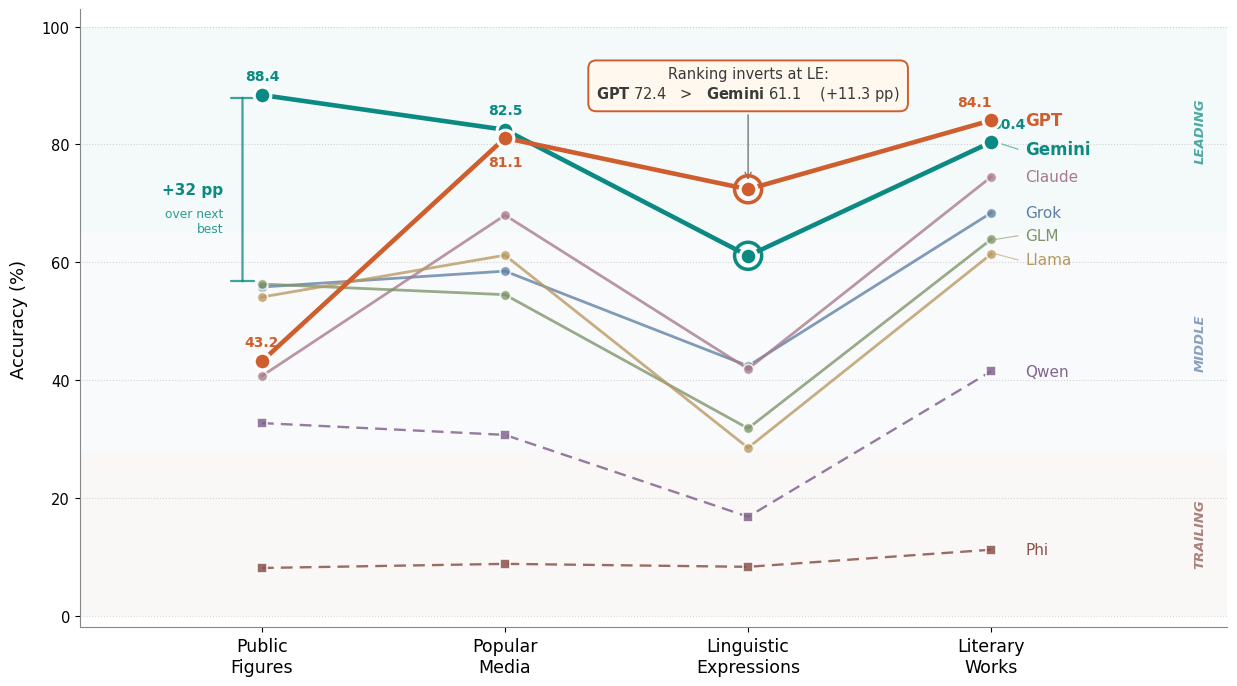

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# ============================================================
# DATA
# ============================================================
domains = ['Public\nFigures', 'Popular\nMedia',
           'Linguistic\nExpressions', 'Literary\nWorks']
x = np.arange(len(domains))

data = {
    'Gemini': [88.4, 82.5, 61.1, 80.4],
    'GPT':    [43.2, 81.1, 72.4, 84.1],
    'Grok':   [55.8, 58.5, 42.4, 68.4],
    'Claude': [40.7, 68.0, 41.9, 74.5],
    'GLM':    [56.3, 54.5, 31.8, 63.9],
    'Llama':  [54.1, 61.2, 28.5, 61.4],
    'Qwen':   [32.7, 30.7, 16.8, 41.5],
    'Phi':    [ 8.1,  8.8,  8.3, 11.2],
}

tier_top = ['Gemini', 'GPT']
tier_mid = ['Grok', 'Claude', 'GLM', 'Llama']
tier_bot = ['Qwen', 'Phi']

# Earth-toned harmonious palette; top tier slightly more saturated
colors = {
    'Gemini': '#0a8a82',   # signature teal
    'GPT':    '#cf5e2e',   # warm rust
    'Grok':   '#5e7fa5',   # dusty blue
    'Claude': '#a87a8b',   # dusty rose
    'GLM':    '#7d9468',   # muted sage
    'Llama':  '#b89860',   # muted ochre
    'Qwen':   '#82658f',   # muted plum
    'Phi':    '#8a544a',   # earthen brown
}

# Right-edge label positions (nudged so close pairs don't collide)
label_y = {
    'GPT':    84.1,
    'Gemini': 79.2,   # leader line will connect to actual 80.4
    'Claude': 74.5,
    'Grok':   68.4,
    'GLM':    64.5,   # nudged up from 63.9
    'Llama':  60.4,   # nudged down from 61.4
    'Qwen':   41.5,
    'Phi':    11.2,
}

# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':      11,
    'axes.labelsize': 13,
})

fig, ax = plt.subplots(figsize=(12.5, 7))

# ============================================================
# TIER BANDS  (very subtle backgrounds)
# ============================================================
ax.axhspan(65, 100, alpha=0.045, color='#0a8a82', zorder=0, lw=0)
ax.axhspan(28, 65,  alpha=0.035, color='#5e7fa5', zorder=0, lw=0)
ax.axhspan(0,  28,  alpha=0.040, color='#8a544a', zorder=0, lw=0)

# Vertical tier indicators in the far-right margin
tx = 3.86
for y, lbl, c in [(82.5, 'LEADING',  '#0a8a82'),
                  (46.5, 'MIDDLE',   '#5e7fa5'),
                  (14.0, 'TRAILING', '#8a544a')]:
    ax.text(tx, y, lbl, color=c, ha='center', va='center',
            fontsize=9.5, fontweight='bold', alpha=0.72,
            rotation=90, style='italic')

# ============================================================
# LINES   (drawn back-to-front: mid → bot → top)
# ============================================================
for m in tier_mid:
    ax.plot(x, data[m], color=colors[m], lw=2.0, alpha=0.78,
            marker='o', markersize=7.5, mec='white', mew=1.3, zorder=2)

for m in tier_bot:
    ax.plot(x, data[m], color=colors[m], lw=1.7, alpha=0.85,
            ls=(0, (5, 3)),
            marker='s', markersize=6.5, mec='white', mew=1.3, zorder=2)

for m in tier_top:
    ax.plot(x, data[m], color=colors[m], lw=3.3, alpha=1.0,
            marker='o', markersize=12, mec='white', mew=2.2, zorder=5)

# ============================================================
# PER-POINT VALUES for top tier (LE skipped — handled by callout)
# ============================================================
top_offsets = {
    'Gemini': {0: (0, 14), 1: (0, 14), 3: (12, 13)},
    'GPT':    {0: (0, 14), 1: (0, -17), 3: (-12, 13)},
}
for m, off_dict in top_offsets.items():
    for j, off in off_dict.items():
        ax.annotate(f'{data[m][j]:.1f}', (x[j], data[m][j]), xytext=off,
                    textcoords='offset points', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=colors[m])

# ============================================================
# RIGHT-EDGE MODEL LABELS  (with leader lines where nudged)
# ============================================================
for m, ly in label_y.items():
    ay = data[m][-1]
    if abs(ly - ay) > 0.6:
        ax.plot([3.02, 3.11], [ay, ly],
                color=colors[m], lw=0.9, alpha=0.55, zorder=3)
    is_top = m in tier_top
    ax.text(3.14, ly, m, ha='left', va='center',
            fontsize=12 if is_top else 11,
            fontweight='bold' if is_top else 'normal',
            color=colors[m])

# ============================================================
# ANNOTATION 1 — Gemini's +32 pp lead on Public Figures
# ============================================================
bracket = FancyArrowPatch((-0.08, 56.3), (-0.08, 88.4),
                          arrowstyle='|-|', color=colors['Gemini'],
                          mutation_scale=8, lw=1.6, alpha=0.78, zorder=4)
ax.add_patch(bracket)
ax.text(-0.16, 72.4, '+32 pp', ha='right', va='center',
        fontsize=11, color=colors['Gemini'], fontweight='bold')
ax.text(-0.16, 67.0, 'over next\nbest', ha='right', va='center',
        fontsize=8.8, color=colors['Gemini'], alpha=0.85)

# ============================================================
# ANNOTATION 2 — GPT > Gemini at Linguistic Expressions
# ============================================================
# Highlight rings around both data points
ax.scatter([2], [data['GPT'][2]],    s=380, facecolor='none',
           edgecolor=colors['GPT'],    lw=2.5, zorder=6)
ax.scatter([2], [data['Gemini'][2]], s=380, facecolor='none',
           edgecolor=colors['Gemini'], lw=2.5, zorder=6)

# Callout box
ax.text(2, 87,
        'Ranking inverts at LE:\n'
        r'$\bf{GPT}$ 72.4   >   $\bf{Gemini}$ 61.1    (+11.3 pp)',
        ha='center', va='bottom', fontsize=10.5, color='#3a3a3a',
        bbox=dict(boxstyle='round,pad=0.55',
                  facecolor='#fff8ee',
                  edgecolor=colors['GPT'], lw=1.4))
ax.annotate('', xy=(2, 73.5), xytext=(2, 85.5),
            arrowprops=dict(arrowstyle='->', color='#777', lw=1.0))

# ============================================================
# AXES POLISH
# ============================================================
ax.set_xticks(x)
ax.set_xticklabels(domains, fontsize=12.5)
ax.set_ylabel('Accuracy (%)', fontsize=13, labelpad=10)
ax.set_ylim(-2, 103)
ax.set_xlim(-0.75, 3.97)
ax.tick_params(axis='y', labelsize=10.5)
ax.grid(True, axis='y', ls=':', alpha=0.4, color='#999')
ax.set_axisbelow(True)

for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
for s in ('left', 'bottom'):
    ax.spines[s].set_color('#888')
    ax.spines[s].set_linewidth(0.8)

plt.tight_layout()
plt.savefig('domain_profile.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

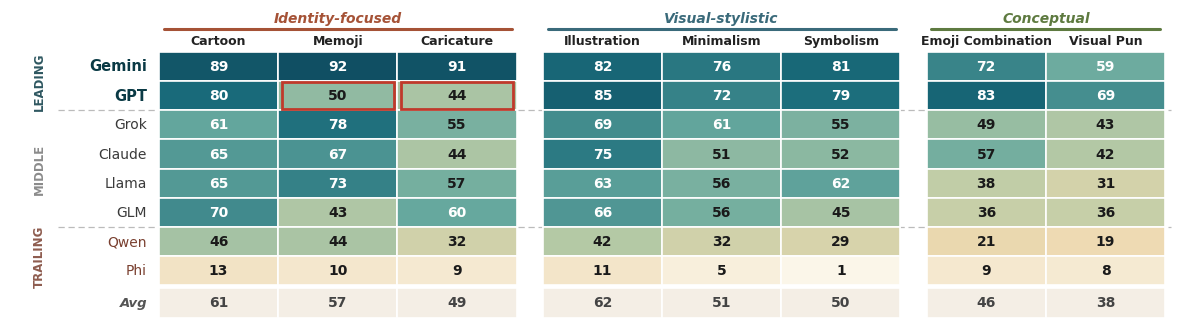

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

# ============================================================
# DATA
# ============================================================
models = ['Gemini', 'GPT', 'Grok', 'Claude', 'Llama', 'GLM', 'Qwen', 'Phi']

style_groups = [
    ('Identity-focused',  ['Cartoon', 'Memoji', 'Caricature']),
    ('Visual-stylistic',  ['Illustration', 'Minimalism', 'Symbolism']),
    ('Conceptual',        ['Emoji Combination', 'Visual Pun']),
]
styles_flat = [s for g in style_groups for s in g[1]]

matrix = np.array([
    [89.13, 92.05, 90.62, 82.04, 75.84, 81.25, 71.65, 58.53],   # Gemini
    [80.43, 50.00, 44.42, 84.62, 72.48, 78.91, 82.59, 68.64],   # GPT
    [60.87, 78.41, 55.47, 69.25, 61.07, 54.69, 48.69, 43.21],   # Grok
    [65.22, 67.05, 44.00, 75.15, 51.01, 51.56, 57.01, 42.49],   # Claude
    [65.22, 72.73, 56.62, 63.35, 55.70, 61.72, 38.06, 31.21],   # Llama
    [69.57, 43.18, 60.06, 65.93, 56.38, 45.31, 35.90, 36.13],   # GLM
    [45.65, 44.32, 32.12, 41.94, 32.21, 28.91, 21.42, 19.08],   # Qwen
    [13.04, 10.23,  8.65, 11.44,  5.37,  0.78,  9.40,  8.38],   # Phi
])
style_means = matrix.mean(axis=0)
n_rows, n_cols = matrix.shape

# ============================================================
# STYLE
# ============================================================
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9})

cmap = LinearSegmentedColormap.from_list("teal_cream", [
    (0.985, 0.965, 0.92),
    (0.93,  0.85,  0.69),
    (0.74,  0.80,  0.65),
    (0.40,  0.66,  0.62),
    (0.10,  0.42,  0.48),
    (0.04,  0.24,  0.33),
], N=256)
norm = Normalize(vmin=0, vmax=100)

group_color = {
    'Identity-focused': '#a55236',
    'Visual-stylistic': '#3a6a7a',
    'Conceptual':       '#5e7a40',
}

# ============================================================
# FIGURE  ───  wide & short (< 1/3 page tall)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 3.4))
fig.patch.set_facecolor('white')

CELL_W, CELL_H = 1.0, 1.0           # data units — aspect set by figsize
GROUP_GAP = 0.22

col_x, acc = [], 0.0
for gi, (_, gst) in enumerate(style_groups):
    for _ in gst:
        col_x.append(acc); acc += CELL_W
    if gi < len(style_groups) - 1:
        acc += GROUP_GAP

# ---- Heatmap cells ----
for i in range(n_rows):
    for j in range(n_cols):
        val = matrix[i, j]
        y, x = n_rows - 1 - i, col_x[j]
        ax.add_patch(Rectangle((x, y), CELL_W, CELL_H,
                               facecolor=cmap(norm(val)),
                               edgecolor='white', linewidth=1.2))
        tc = 'white' if val > 58 else '#1a1a1a'
        ax.text(x + CELL_W/2, y + CELL_H/2, f"{val:.0f}",
                ha='center', va='center', color=tc,
                fontsize=10, fontweight='bold', zorder=5)

# ---- Model labels (left) ----
for i, m in enumerate(models):
    y = n_rows - 1 - i
    if m in ('Gemini', 'GPT'):
        kw = dict(color='#0a3a45', fontweight='bold', fontsize=10.5)
    elif m in ('Qwen', 'Phi'):
        kw = dict(color='#7a4030', fontsize=10)
    else:
        kw = dict(color='#3a3a3a', fontsize=10)
    ax.text(-0.10, y + CELL_H/2, m, ha='right', va='center', **kw)

# ---- Style labels (top, hugging the cells) ----
style_label_y = n_rows + 0.16
for j, s in enumerate(styles_flat):
    ax.text(col_x[j] + CELL_W/2, style_label_y, s,
            ha='center', va='bottom',
            fontsize=9, color='#222', fontweight='bold')

# ---- Category name + thin colored underline ----
cat_line_y = n_rows + 0.78
cat_text_y = n_rows + 0.90
start = 0
for gname, gst in style_groups:
    end = start + len(gst) - 1
    xl, xr = col_x[start], col_x[end] + CELL_W
    c = group_color[gname]
    ax.plot([xl + 0.04, xr - 0.04], [cat_line_y, cat_line_y],
            color=c, lw=2.2, solid_capstyle='round')
    ax.text((xl + xr) / 2, cat_text_y, gname,
            ha='center', va='bottom', fontsize=10, color=c,
            fontweight='bold', style='italic')
    start += len(gst)

# ---- Avg row (style means at the bottom) ----
avg_y = -1.10
for j in range(n_cols):
    val = style_means[j]
    x = col_x[j]
    ax.add_patch(Rectangle((x, avg_y), CELL_W, CELL_H,
                           facecolor='#f4eee5', edgecolor='white', linewidth=1.2))
    ax.text(x + CELL_W/2, avg_y + CELL_H/2, f"{val:.0f}",
            ha='center', va='center', fontsize=10, fontweight='bold', color='#444')
ax.text(-0.10, avg_y + CELL_H/2, "Avg", ha='right', va='center',
        fontsize=9.5, fontweight='bold', color='#555', style='italic')

# ---- Tier dividers ----
sep_xs, sep_xe = -0.85, col_x[-1] + CELL_W + 0.05
for y_sep in [n_rows - 2, 2]:
    ax.plot([sep_xs, sep_xe], [y_sep, y_sep], color='#bbb',
            ls=(0, (5, 3)), lw=0.9, zorder=0)

# ---- Tier labels (rotated, far left) ----
for y, lbl, c in [(7, "LEADING", '#0a3a45'),
                  (4, "MIDDLE",  '#777'),
                  (1, "TRAILING",'#7a4030')]:
    ax.text(-1.00, y, lbl, fontsize=8.5, fontweight='bold', color=c,
            rotation=90, va='center', ha='center', alpha=0.85)

# ---- Red outlines: GPT's identity-style anomaly ----
gpt_y = n_rows - 1 - models.index('GPT')
for col_name in ['Memoji', 'Caricature']:
    c_idx = styles_flat.index(col_name)
    x = col_x[c_idx]
    ax.add_patch(Rectangle((x + 0.03, gpt_y + 0.03),
                           CELL_W - 0.06, CELL_H - 0.06,
                           facecolor='none', edgecolor='#c0392b',
                           linewidth=2, zorder=8))

# ---- Layout ----
ax.set_xlim(-1.25, col_x[-1] + CELL_W + 0.15)
ax.set_ylim(avg_y - 0.15, cat_text_y + 0.55)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('style_heatmap_compact.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

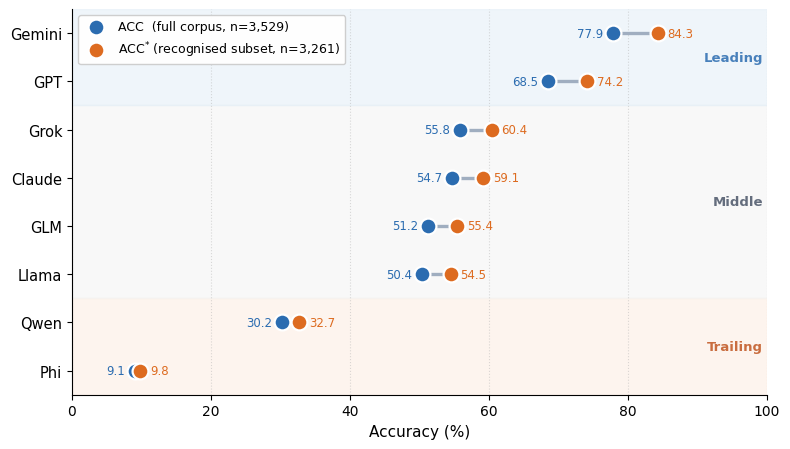

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Data (sorted ascending so leaders sit at the top) ──────────────────
models   = ['Phi', 'Qwen', 'Llama', 'GLM', 'Claude', 'Grok', 'GPT', 'Gemini']
acc      = [ 9.07, 30.21, 50.35, 51.20, 54.66, 55.82, 68.52, 77.90]
acc_star = [ 9.81, 32.69, 54.49, 55.41, 59.15, 60.41, 74.15, 84.30]
tier_of  = [ 'T',  'T',   'M',    'M',   'M',     'M',   'L',  'L'  ]   # Trailing/Middle/Leading

# ─── Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.6))
y = np.arange(len(models))

# Tier background bands (computed from contiguous runs of tier_of)
band = {'T': '#fdebe1', 'M': '#f3f3f3', 'L': '#e3eef7'}
edges, prev, start = [], tier_of[0], -0.5
for i, t in enumerate(tier_of):
    if t != prev:
        edges.append((start, i - 0.5, prev))
        start, prev = i - 0.5, t
edges.append((start, len(models) - 0.5, prev))
for s, e, t in edges:
    ax.axhspan(s, e, color=band[t], alpha=0.55, zorder=0)

# Colors
c_acc, c_star, c_link = '#2b6cb0', '#dd6b20', '#a0aec0'

# Dumbbell connectors
for i, (a, b) in enumerate(zip(acc, acc_star)):
    ax.plot([a, b], [i, i], color=c_link, linewidth=2.4, zorder=1)

# Markers
ax.scatter(acc,      y, s=130, color=c_acc,  edgecolor='white', linewidth=1.6,
           zorder=3, label='ACC  (full corpus, n=3,529)')
ax.scatter(acc_star, y, s=130, color=c_star, edgecolor='white', linewidth=1.6,
           zorder=3, label=r'ACC$^{*}$ (recognised subset, n=3,261)')

# Numeric labels next to each dot
for i, (a, b) in enumerate(zip(acc, acc_star)):
    ax.text(a - 1.4, i, f'{a:.1f}', va='center', ha='right',
            fontsize=8.5, color=c_acc)
    ax.text(b + 1.4, i, f'{b:.1f}', va='center', ha='left',
            fontsize=8.5, color=c_star)

# Right-side tier annotations
tier_text = {'L': 'Leading', 'M': 'Middle', 'T': 'Trailing'}
tier_clr  = {'L': '#2b6cb0', 'M': '#4a5568', 'T': '#c05621'}
for s, e, t in edges:
    ax.text(99.5, (s + e) / 2, tier_text[t], color=tier_clr[t],
            ha='right', va='center', fontsize=9.5,
            fontweight='bold', alpha=0.85)

# Axes cosmetics
ax.set_yticks(y); ax.set_yticklabels(models, fontsize=10.5)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_xlim(0, 100); ax.set_ylim(-0.5, len(models) - 0.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.45); ax.set_axisbelow(True)
ax.legend(loc='upper left', frameon=True, fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig('fig/overall_acc.pdf', bbox_inches='tight')
plt.savefig('fig/overall_acc.png', dpi=300, bbox_inches='tight')
plt.show()